In [ ]:
from binance.client import Client
import pandas as pd  # Opcional, para verlos bonito en un DataFrame
from datetime import datetime
import math
client = Client()

# Últimos 90 días aproximados en intervalo diario
klines = client.get_historical_klines(
    "BTCUSDT", 
    Client.KLINE_INTERVAL_1MINUTE, 
    "360 days ago UTC"  # Binance acepta strings como este
)

#aca loq ue vamos a hacer es entrenar con el 20% de los datos y trabajar con el resto   
listaprecios= []
listaFit=[]
for i in range(len(klines)):
    if(i<math.floor(len(klines)*0.2)):
        listaFit.append(float(klines[i][4]))
    else:
        listaprecios.append(float(klines[i][4]))

print(len(listaprecios))
print(listaFit)

In [1]:
# vamos a usar lognorm

In [ ]:
from strategies.logNormal import LogNorm
umbral = 0.15
moneda = "BTCUSDT"
inversionInicial = 10 #asumimos dolares
ln = LogNorm(listaFit,umbral)
for i in range(len(listaprecios)):
    ln.priceSignal(listaprecios[i],inversionInicial,moneda)
print(ln.ganancia_total_acumulada)



In [ ]:
import time
from binance.client import Client
from binance_connection import ConexionABinance
from strategies.logNormal import LogNorm

# Configuración
SIMBOLOS = ["BTCUSDT", "ETHUSDT", "SOLUSDT", "ADAUSDT"]  # Agregá las que quieras
CAPITAL_INICIAL_POR_MONEDA = 5.0
UMBRAL = 0.15
VENTANA = 500
INTERVALO = 60

conexion = ConexionABinance()
client = conexion.cliente()

# Diccionario de estrategias
estrategias = {}

print("Cargando datos iniciales para cada moneda...")
for simbolo in SIMBOLOS:
    klines = client.get_historical_klines(simbolo, Client.KLINE_INTERVAL_1MINUTE, f"{VENTANA + 100} minutes ago UTC")
    precios = [float(k[4]) for k in klines[-VENTANA:]]
    estrategias[simbolo] = LogNorm(precios, umbral=UMBRAL, capital_inicial_usdt=CAPITAL_INICIAL_POR_MONEDA)

print(f"\n=== BOT MULTI-MONEDA LIVE ({len(SIMBOLOS)} pares) ===\n")

try:
    while True:
        for simbolo, estrategia in estrategias.items():
            ticker = client.get_symbol_ticker(symbol=simbolo)
            precio = float(ticker['price'])
            estrategia.priceUpdate(precio)
            estrategia.priceSignal(precio, simbolo)
        print("-" * 60)
        time.sleep(INTERVALO)

except KeyboardInterrupt:
    total = sum(est.capital_usdt + (est.cantidad_crypto * client.get_symbol_ticker(symbol=s)['price']) 
                if not est.en_posicion else est.cantidad_crypto * client.get_symbol_ticker(symbol=s)['price']
                for s, est in estrategias.items())
    print(f"\nBot detenido. Valor total estimado de la cartera: {total:.2f} USDT")

Monedas USDT activas: 30 → Iniciando backtest...

[1/30] Procesando BTCUSDT...

Descargando datos y preparando estrategias (sin prints detallados)...
[08:49:49] COMPRA | Precio: 87492.73 | Invertimos: 10.00 USDT → 0.00011418 BTC (comisión: 0.1%)
[08:49:49] Espera | Precio: 87499.70 | Prob: 0.0066 | EN POSICIÓN | Cartera: 9.99 USDT
[08:49:49] Espera | Precio: 87507.84 | Prob: 0.0079 | EN POSICIÓN | Cartera: 9.99 USDT
[08:49:49] Espera | Precio: 87507.83 | Prob: 0.0079 | EN POSICIÓN | Cartera: 9.99 USDT
[08:49:49] Espera | Precio: 87507.84 | Prob: 0.0079 | EN POSICIÓN | Cartera: 9.99 USDT
[08:49:49] Espera | Precio: 87552.00 | Prob: 0.0191 | EN POSICIÓN | Cartera: 10.00 USDT
[08:49:49] Espera | Precio: 87566.00 | Prob: 0.0248 | EN POSICIÓN | Cartera: 10.00 USDT
[08:49:49] Espera | Precio: 87566.00 | Prob: 0.0248 | EN POSICIÓN | Cartera: 10.00 USDT
[08:49:49] Espera | Precio: 87581.26 | Prob: 0.0325 | EN POSICIÓN | Cartera: 10.00 USDT
[08:49:49] Espera | Precio: 87581.27 | Prob: 0.0325 | EN POSICIÓN | Cartera: 10.00 USDT
[08:49:49] Espera | Precio: 87565.99 | Prob: 0

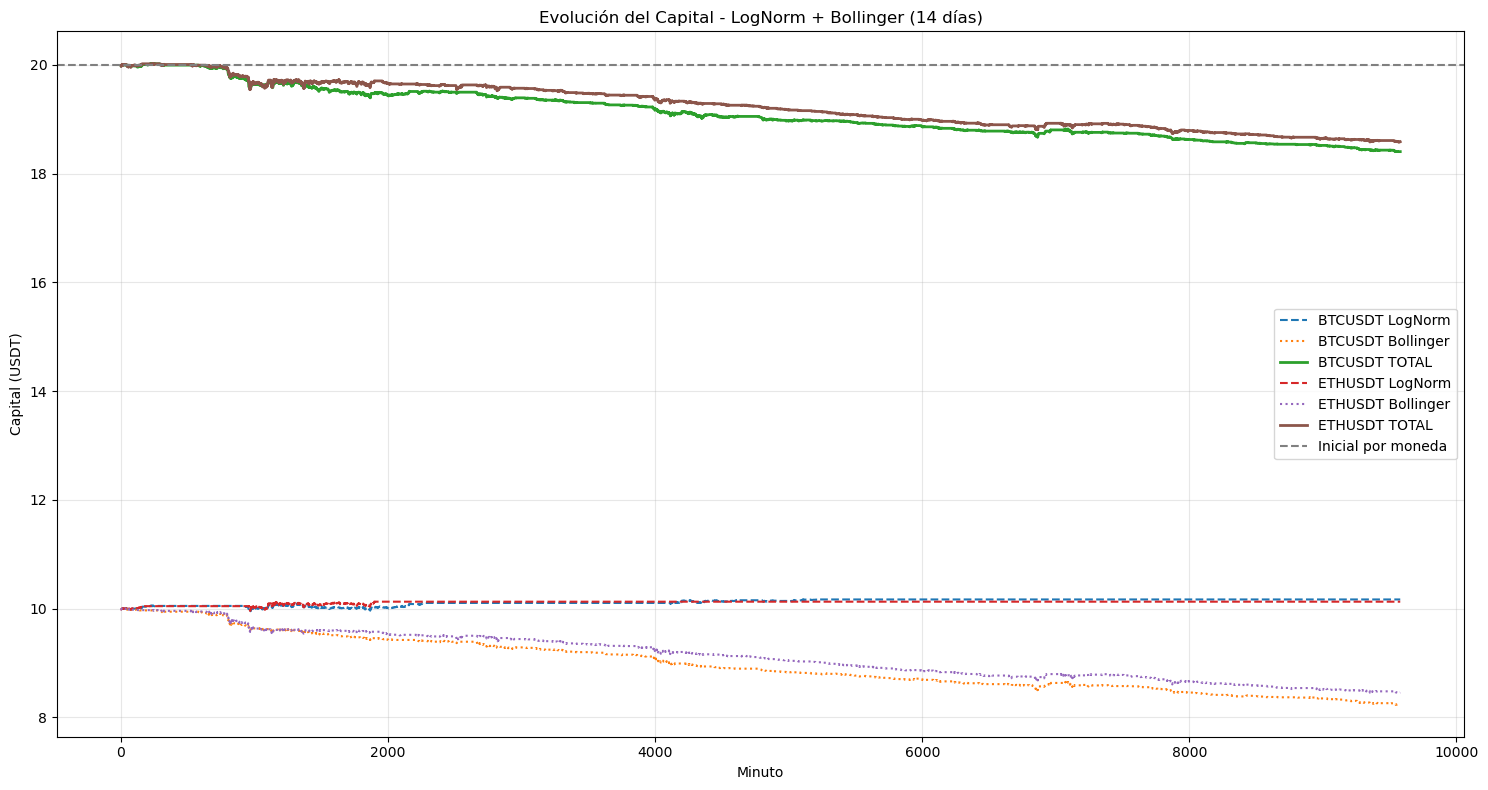

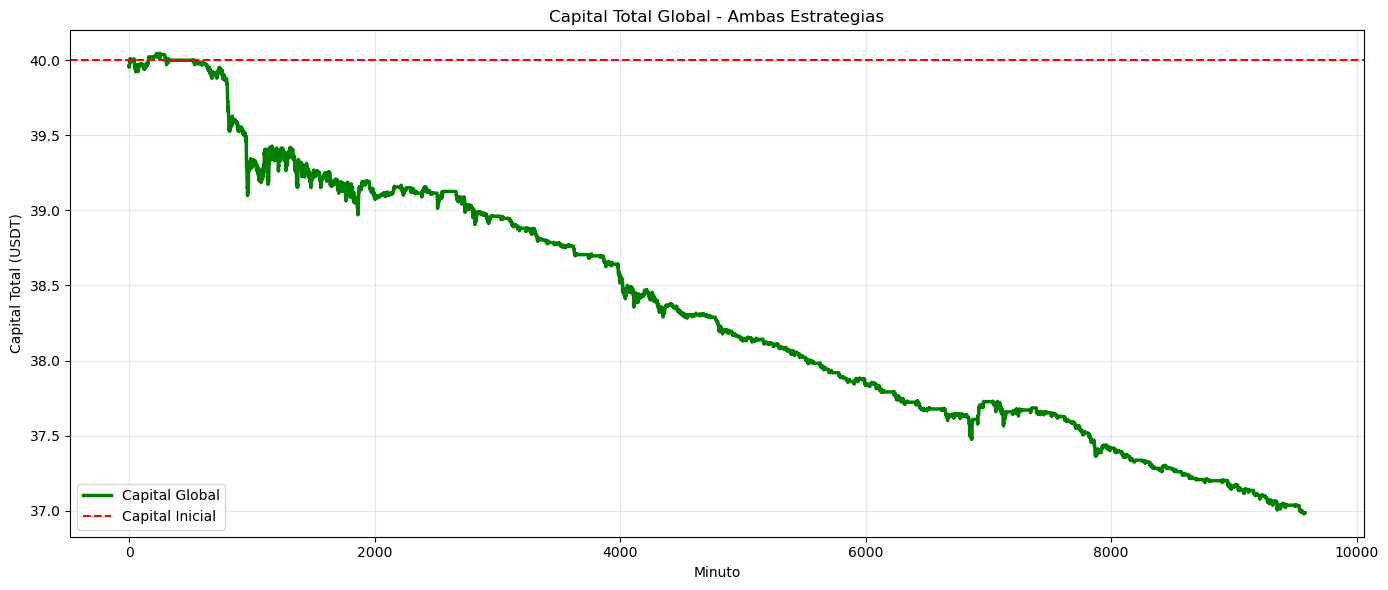

In [3]:
import time
import numpy as np
import matplotlib.pyplot as plt
from binance.client import Client
from strategies.logNormal import LogNorm
from strategies.bollinger import Bollinger

# ========================= CONFIGURACIÓN BACKTEST 14 DÍAS =========================
SIMBOLOS = ["BTCUSDT", "ETHUSDT"]
CAPITAL_INICIAL_POR_ESTRATEGIA = 10.0   # 10 USDT por estrategia → 40 USDT total
UMBRAL_LOGNORM = 0.15
VENTANA_LOGNORM = 500
VENTANA_BOLLINGER = 20
PERIOD = "7 days ago UTC"

client = Client()

estrategias = {}
historial_capital_lognorm = {s: [] for s in SIMBOLOS}
historial_capital_bollinger = {s: [] for s in SIMBOLOS}
historial_capital_total = {s: [] for s in SIMBOLOS}

print("Descargando datos y preparando estrategias (sin prints detallados)...")

for simbolo in SIMBOLOS:
    klines = client.get_historical_klines(simbolo, Client.KLINE_INTERVAL_1MINUTE, PERIOD)
    if len(klines) < max(VENTANA_LOGNORM, VENTANA_BOLLINGER) + 100:
        continue
    
    precios = [float(k[4]) for k in klines]
    
    # LogNorm
    lognorm = LogNorm(
        lista_precios_inicial=precios[:VENTANA_LOGNORM],
        umbral=UMBRAL_LOGNORM,
        capital_inicial_usdt=CAPITAL_INICIAL_POR_ESTRATEGIA,
        comision=0.001,
        stop_loss_pct=0.15
    )
    
    # Bollinger
    bollinger = Bollinger(
        data_inicial=precios[:VENTANA_BOLLINGER],
        periodo=VENTANA_BOLLINGER,
        desvios=2.0,
        capital_inicial_usdt=CAPITAL_INICIAL_POR_ESTRATEGIA,
        comision=0.001
    )
    
    estrategias[simbolo] = {"lognorm": lognorm, "bollinger": bollinger}

# ========================= BACKTEST SIN PRINTS =========================
inicio = max(VENTANA_LOGNORM, VENTANA_BOLLINGER)
precios_global = None  # Usaremos los precios del último símbolo cargado

for simbolo in estrategias:
    klines = client.get_historical_klines(simbolo, Client.KLINE_INTERVAL_1MINUTE, PERIOD)
    precios = [float(k[4]) for k in klines]
    precios_global = precios  # Guardamos para gráficos
    
    for i in range(inicio, len(precios)):
        precio = precios[i]
        
        strats = estrategias[simbolo]
        # Procesamos sin prints
        strats["lognorm"].priceSignal(precio, simbolo)
        strats["bollinger"].signal(precio, simbolo)
        
        capital_lognorm = (strats["lognorm"].cantidad_crypto * precio 
                          if strats["lognorm"].en_posicion else strats["lognorm"].capital_usdt)
        capital_bollinger = strats["bollinger"].get_capital_actual(precio)
        capital_total_moneda = capital_lognorm + capital_bollinger
        
        historial_capital_lognorm[simbolo].append(capital_lognorm)
        historial_capital_bollinger[simbolo].append(capital_bollinger)
        historial_capital_total[simbolo].append(capital_total_moneda)

# ========================= RESUMEN FINAL SOLO =========================
print("\n" + "="*80)
print("RESUMEN FINAL BACKTEST 14 DÍAS - LOGNORM + BOLLINGER EN PARALELO")
print("="*80)

capital_final_total = 0.0
for simbolo in estrategias:
    precio_final = precios_global[-1]
    logn = estrategias[simbolo]["lognorm"]
    boll = estrategias[simbolo]["bollinger"]
    
    final_lognorm = (logn.cantidad_crypto * precio_final if logn.en_posicion else logn.capital_usdt)
    final_bollinger = boll.get_capital_actual(precio_final)
    total_simbolo = final_lognorm + final_bollinger
    capital_final_total += total_simbolo
    
    print(f"{simbolo}")
    print(f"   LogNorm:     {final_lognorm:8.2f} USDT")
    print(f"   Bollinger:   {final_bollinger:8.2f} USDT")
    print(f"   TOTAL:       {total_simbolo:8.2f} USDT\n")

capital_inicial_total = len(estrategias) * 2 * CAPITAL_INICIAL_POR_ESTRATEGIA
rendimiento = (capital_final_total / capital_inicial_total - 1) * 100

print(f"CAPITAL INICIAL TOTAL: {capital_inicial_total:.2f} USDT")
print(f"CAPITAL FINAL TOTAL:   {capital_final_total:.2f} USDT")
print(f"RENDIMIENTO TOTAL:     {rendimiento:+.2f}%")

# ========================= GRÁFICOS (sin prints intermedios) =========================
longitud = min(len(historial_capital_total[s]) for s in SIMBOLOS if s in historial_capital_total)

plt.figure(figsize=(15, 8))
for simbolo in estrategias:
    plt.plot(historial_capital_lognorm[simbolo][:longitud], label=f'{simbolo} LogNorm', linestyle='--')
    plt.plot(historial_capital_bollinger[simbolo][:longitud], label=f'{simbolo} Bollinger', linestyle=':')
    plt.plot(historial_capital_total[simbolo][:longitud], label=f'{simbolo} TOTAL', linewidth=2)

plt.title('Evolución del Capital - LogNorm + Bollinger (14 días)')
plt.xlabel('Minuto')
plt.ylabel('Capital (USDT)')
plt.axhline(y=CAPITAL_INICIAL_POR_ESTRATEGIA*2, color='gray', linestyle='--', label='Inicial por moneda')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Capital global
capital_global = [sum(historial_capital_total[s][i] for s in estrategias if i < len(historial_capital_total[s])) for i in range(longitud)]

plt.figure(figsize=(14, 6))
plt.plot(capital_global, color='green', linewidth=2.5, label='Capital Global')
plt.title('Capital Total Global - Ambas Estrategias')
plt.xlabel('Minuto')
plt.ylabel('Capital Total (USDT)')
plt.axhline(y=capital_inicial_total, color='red', linestyle='--', label='Capital Inicial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [2]:
#ahora tomamtos los primeros 200 datos para calcular los parametros de las bandas de bollinger
#entonces voy a tener 2 listas, 1 para entrenar mi modulo bollinger y otra para ir testeando la estrategia

In [ ]:
from strategies.bollinger import Bollinger
b = Bollinger(listaFit)
listaDeVectoresSobreVenta = []
listaDeVectoresSobreCompra = []
vector = []
for i in range(len(listaprecios)-1):
    print(f"la diferencia entre el valor actual de BTC:{listaprecios[i]} y la banda superior: {b.topBand()} es: \n {listaprecios[i]-b.topBand()}")
    

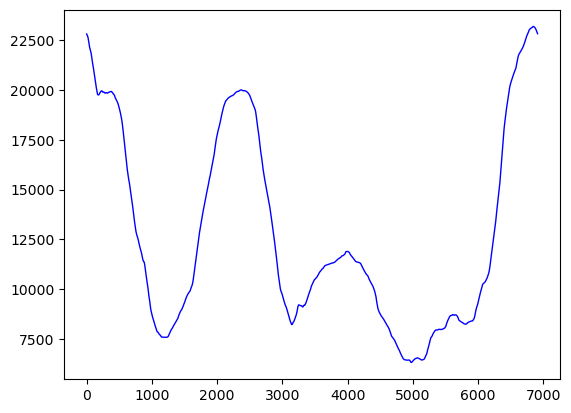

AttributeError: 'list' object has no attribute 'mean'

In [22]:
#grafico la diferencia entre las bandas superior e inferior
import matplotlib.pyplot as plt
import numpy as np
y=[]
x = np.linspace(0,len(listaprecios),len(listaprecios))
for i in range(len(listaprecios)):
    y.append(b.topBand() - b.lowerBand())
    b.updateAtributes(listaprecios[i])
plt.plot(x,y,label="dif bands",color="blue",linewidth=1)
plt.show()


In [27]:
print(np.std(y)/np.mean(y))

0.3912914368174271
